In [22]:
#using dbscam
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [3]:
X,y=make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42
)

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

<Axes: >

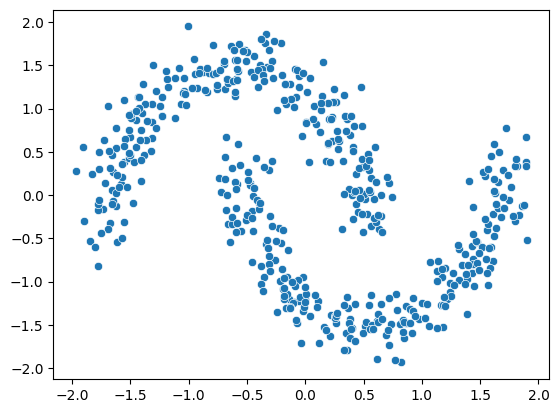

In [5]:
#visualization
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1])

In [10]:
#DBSCAN
dbscan=DBSCAN(
    eps= 0.18,
    min_samples=5,
)
labels=dbscan.fit_predict(X_scaled)

<Axes: >

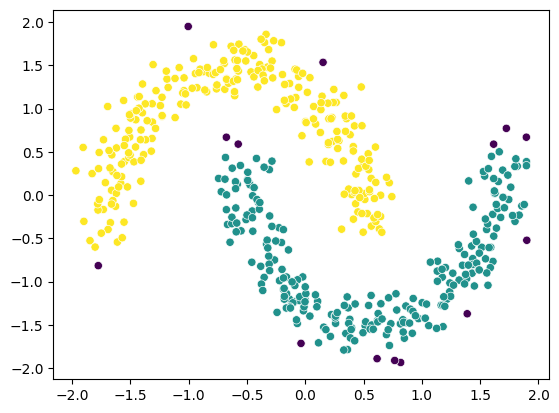

In [11]:
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],c=labels)

In [ ]:
#using isolation forest

In [23]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [24]:
df=pd.read_csv('thyroid_dataset.csv')

In [25]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [26]:
X=df.drop('Outlier_label',axis=1)
y=df['Outlier_label']

In [32]:
scaler=StandardScaler()


In [33]:
X_scaled=scaler.fit_transform(X)

In [43]:
from sklearn.ensemble import IsolationForest
clf=IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42
)

In [44]:
labels=clf.fit_predict(X_scaled)

In [45]:
from sklearn.decomposition import PCA
pca=PCA(
    n_components=2
)

In [46]:
X_pca=pca.fit_transform(X_scaled)

Text(0, 0.5, 'pc2')

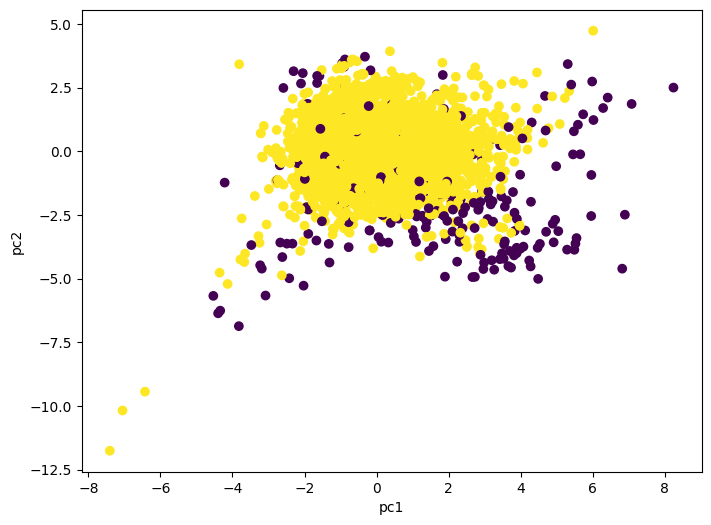

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel('pc1')
plt.ylabel('pc2')

In [48]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)

In [49]:
print("outliers=",n_outliers)
print("normal=",n_normal)

outliers= 249
normal= 6667


In [51]:
#lof
from sklearn.neighbors import LocalOutlierFactor

In [54]:
neighbs=LocalOutlierFactor(contamination=0.036)
labels=neighbs.fit_predict(X_scaled)

Text(0, 0.5, 'pc2')

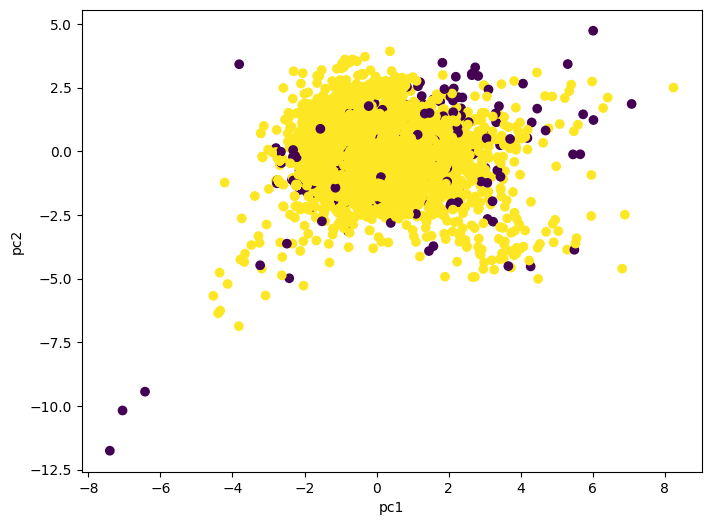

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel('pc1')
plt.ylabel('pc2')